In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib.ticker import ScalarFormatter

In [2]:
fp1c = 'data/wco_time_series/ESSD_Coccolithophores_revised_2013.xlsx'
df1c = pd.read_excel(fp1c, sheet_name='All datapoints')
df1c = df1c.loc[
    (df1c['Institute'] == 'Western Channel Observatory') &
    (df1c['Species/lowest classification'] == 'Emiliania huxleyi'),
    ['Year', 'Month ', 'Day', 'Species/lowest classification', 'Biovolume Category', 'Cells/l']
].copy()
df1c.rename(columns={'Month ': 'Month'}, inplace=True)
df1c['Date'] = pd.to_datetime({'year': df1c['Year'], 'month': df1c['Month'], 'day': df1c['Day']})
df1c = df1c.set_index('Date')
df1c['Cells/mL'] = (df1c['Cells/l'] / 1000).round()
df1c['Cells/mL'] = df1c['Cells/mL'].clip(lower=1).fillna(1)
df1c['MonthStart'] = df1c.index.to_period('M').to_timestamp()

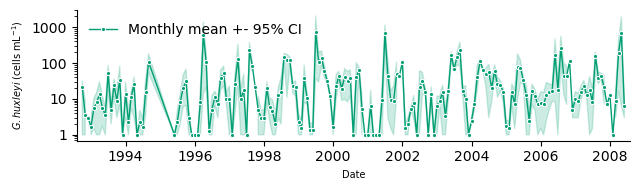

In [3]:
colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']
fig, ax = plt.subplots(figsize=(6.5, 2))
sns.lineplot(
    data=df1c, x='MonthStart', y='Cells/mL',
    errorbar=('ci', 95), color=colors[2], linewidth=1,
    marker='o', markersize=3, ax=ax,
    label='Monthly mean +- 95% CI'
)
ax.set_xlim(df1c['MonthStart'].min() - timedelta(days=60),
            df1c['MonthStart'].max() + timedelta(days=60))
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_xlabel('Date', size=7)
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL$^{-1})$', size=7)
ax.legend(frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig('figures/wco_time_series.png', dpi=600, bbox_inches="tight")
plt.savefig('figures/wco_time_series.pdf', dpi=600, bbox_inches="tight")